# 10-Year 105,120 5-Minute Interval HMM Transition Analysis & Dataset Generation (v2 — mean-Only Feature)

## Objectives
1. **Load 10-Year 5-Minute Rainfall Data (4-Gauge Average)**: Aggregate 5-minute spatial average rainfall records across all 4 rain gauges in Astlingen (2000–2009) into a 10-year 5-minute dataset (1,051,200 records).
2. **Construct 1-Year (105,120 5-Minute Interval) Climatological mean Profile**: Rather than extracting multiple multi-metric daily features (sum, max, zero fraction), compute the 10-year **mean** rainfall intensity directly per 5-minute annual interval position (365 days × 288 intervals/day = 105,120 slots) to obtain a robust 1D climatological rainfall profile. Apply a 14-day rolling window (4,032 5-minute steps) for climatological smoothing.
3. **Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D mean Profile**: Train a 4-state GaussianHMM directly on the standardized 105,120 1D climatological mean profile.
4. **Reorder & Characterize HMM States**: Sort state indices (0 to 3) by mean mean rainfall intensity (State 0: Dry/Low Activity, State 1: Light/Moderate Rain, State 2: Heavy/Convective Rain, State 3: Peak/Intense Storms).
5. **Observe & Visualize 105,120-Interval Transition Matrix**: Extract the 4x4 state transition matrix, compute transition dynamics, and render a high-quality heatmap visualization.
6. **Visualize 105,120-Interval Climatological Regimes**: Plot the annual 105,120 5-minute rainfall profile colored by hidden state transitions across the 365-day year.
7. **Broadcast 105,120 HMM State Sequence to Full 5-Minute Dataset**: Map the 105,120 5-minute HMM state sequence back to each 5-minute record in the 10-year dataset (1,051,200 records).
8. **Export New v2 Labeled Dataset**: Save the dataset containing `date`, `time`, `rainfall_intensity`, `day_of_year`, and `hmm_state` to `../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_v2_fit_hmm.csv`.
9. **Visualize Sample 5-Minute Time Series with Broadcasted HMM States**: Render a sample 14-day window of 5-minute rainfall intensity overlaid with background shading for the predicted HMM state regimes.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## Step 1: Load 10-Year 5-Minute Data & Compute 4-Gauge Average
We load all 4 rain gauge datasets (Astlingen Erft 1–4) for 2000–2009, compute the spatial average 5-minute rainfall intensity, and set up annual interval indexing (0 to 105,119).

In [2]:
# Load all 4 raw 5-minute rainfall gauge datasets
file_paths = sorted(glob.glob('../data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))
if not file_paths:
    file_paths = sorted(glob.glob('data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))

print(f"Loading {len(file_paths)} rain gauge datasets:")
for p in file_paths:
    print(f" - {p}")

gauge_dfs = []
for path in file_paths:
    g_df = pd.read_csv(path)
    g_df['datetime'] = pd.to_datetime(g_df['date'] + ' ' + g_df['time'], format='%m/%d/%Y %H:%M:%S')
    g_df.set_index('datetime', inplace=True)
    gauge_dfs.append(g_df['rainfall_intensity'])

# Combine and compute 4-gauge average 5-minute rainfall intensity
df_5min_full = pd.concat(gauge_dfs, axis=1).mean(axis=1).to_frame(name='rainfall_intensity').reset_index()

# Add year, day_of_year, interval_of_day
df_5min_full['year'] = df_5min_full['datetime'].dt.year
df_5min_full['day_of_year'] = df_5min_full['datetime'].dt.dayofyear
df_5min_full['interval_of_day'] = (df_5min_full['datetime'].dt.hour * 12 + df_5min_full['datetime'].dt.minute // 5)

# Calculate annual 5-minute interval index (0 to 105,119)
day_capped = df_5min_full['day_of_year'].clip(upper=365)
df_5min_full['annual_interval_idx'] = (day_capped - 1) * 288 + df_5min_full['interval_of_day']

print(f"Full 10-Year 5-Minute Dataset Shape: {df_5min_full.shape}")
print(df_5min_full.head())

Loading 4 rain gauge datasets:
 - ../data/rainfall/astlingen/1Astlingen_Erft1.csv
 - ../data/rainfall/astlingen/2Astlingen_Erft2.csv
 - ../data/rainfall/astlingen/3Astlingen_Erft3.csv
 - ../data/rainfall/astlingen/4Astlingen_Erft4.csv
Full 10-Year 5-Minute Dataset Shape: (1051200, 6)
             datetime  rainfall_intensity  year  day_of_year  interval_of_day  \
0 2000-01-01 00:00:00               0.005  2000            1                0   
1 2000-01-01 00:05:00               0.000  2000            1                1   
2 2000-01-01 00:10:00               0.000  2000            1                2   
3 2000-01-01 00:15:00               0.000  2000            1                3   
4 2000-01-01 00:20:00               0.000  2000            1                4   

   annual_interval_idx  
0                    0  
1                    1  
2                    2  
3                    3  
4                    4  


## Step 2: Construct 1-Year (105,120 5-Minute Interval) Climatological Median Profile
We aggregate across 10 years by `annual_interval_idx` (0 to 105,119) to compute the **median** rainfall intensity for each 5-minute annual interval slot, then apply a 14-day rolling mean (4,032 5-minute steps) to smooth high-frequency noise into continuous seasonal signals.

In [11]:
# Filter out leap-year day 366 for consistent 365-day annual alignment (365 * 288 = 105,120 intervals)
df_365 = df_5min_full[df_5min_full['day_of_year'] <= 365].copy()

# Compute 10-year median rainfall intensity per annual interval slot
clim_105120 = df_365.groupby('annual_interval_idx').agg(
    median_intensity=('rainfall_intensity', 'median'),
    mean_intensity=('rainfall_intensity', 'mean'),
    day_of_year=('day_of_year', 'first'),
).reset_index().set_index('annual_interval_idx')

# Apply 14-day rolling window (4,032 5-min intervals) to smooth the median profile
clim_105120['median_intensity_smooth'] = clim_105120['median_intensity'].rolling(
    window=4032, min_periods=1, center=True
).mean()

# Also compute smoothed mean for reference comparison
clim_105120['mean_intensity_smooth'] = clim_105120['mean_intensity'].rolling(
    window=4032, min_periods=1, center=True
).mean()

print(f"105,120-interval climatological median profile shape: {clim_105120.shape}")
print(clim_105120.head())

105,120-interval climatological median profile shape: (105120, 5)
                     median_intensity  mean_intensity  day_of_year  \
annual_interval_idx                                                  
0                                 0.0         0.00050            1   
1                                 0.0         0.00075            1   
2                                 0.0         0.00000            1   
3                                 0.0         0.00225            1   
4                                 0.0         0.00250            1   

                     median_intensity_smooth  mean_intensity_smooth  
annual_interval_idx                                                  
0                                   0.000009               0.008204  
1                                   0.000009               0.008200  
2                                   0.000009               0.008195  
3                                   0.000009               0.008191  
4                      

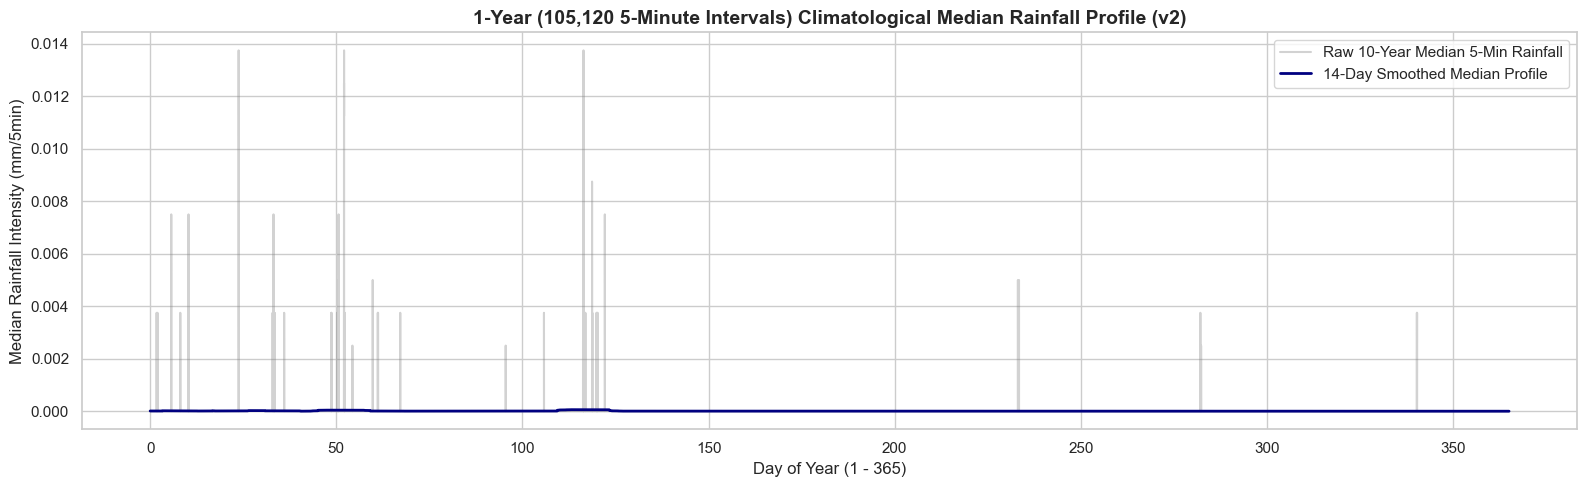

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))
days = clim_105120.index / 288.0

ax.plot(days, clim_105120['median_intensity'], alpha=0.35, color='gray', label='Raw 10-Year Median 5-Min Rainfall')
ax.plot(days, clim_105120['median_intensity_smooth'], color='navy', linewidth=2, label='14-Day Smoothed Median Profile')
ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological Median Rainfall Profile (v2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Median Rainfall Intensity (mm/5min)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

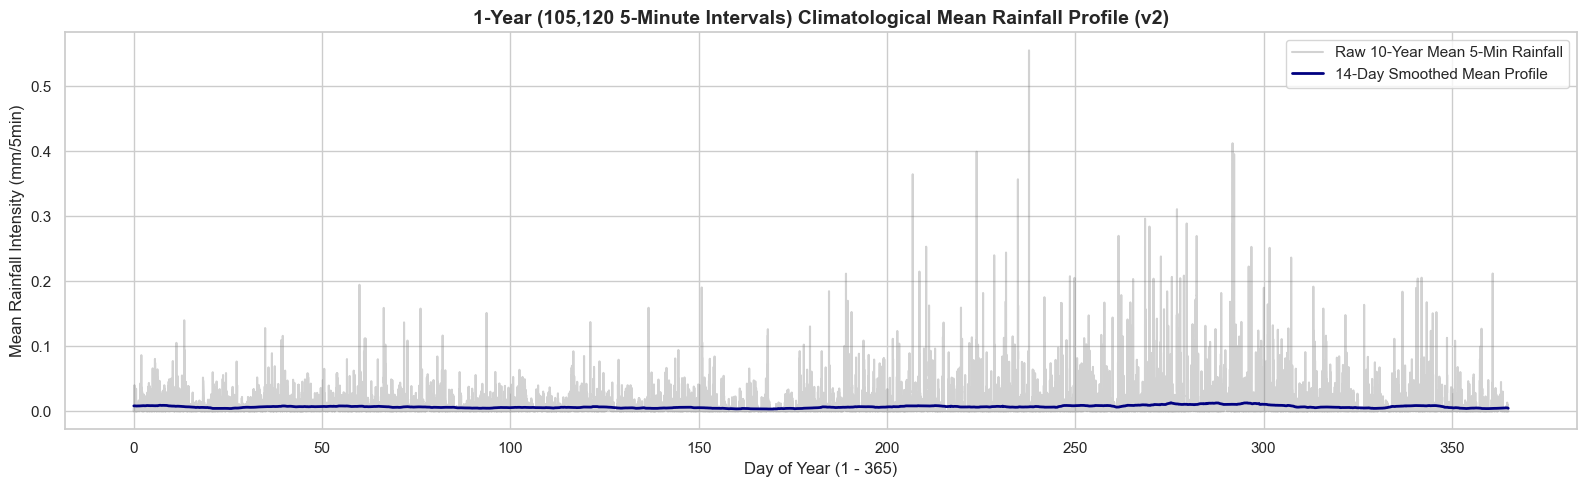

In [13]:
fig, ax = plt.subplots(figsize=(16, 5))
days = clim_105120.index / 288.0

ax.plot(days, clim_105120['mean_intensity'], alpha=0.35, color='gray', label='Raw 10-Year Mean 5-Min Rainfall')
ax.plot(days, clim_105120['mean_intensity_smooth'], color='navy', linewidth=2, label='14-Day Smoothed Mean Profile')
ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological Mean Rainfall Profile (v2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Mean Rainfall Intensity (mm/5min)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Step 3: Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D Median Profile
We standardize the 105,120 1D smoothed median profile and train a 4-state GaussianHMM directly on the 105,120 interval sequence.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clim_105120[['mean_intensity']])

n_states = 4
hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type='full', n_iter=200, random_state=42)
hmm_model.fit(X_scaled)

raw_states = hmm_model.predict(X_scaled)
clim_105120['raw_state'] = raw_states

# Reorder states by mean smoothed mean intensity (0: Lowest -> 3: Highest)
state_means = clim_105120.groupby('raw_state')['mean_intensity'].mean().sort_values()
state_map = {old_st: new_st for new_st, old_st in enumerate(state_means.index)}
clim_105120['hmm_state'] = clim_105120['raw_state'].map(state_map)

# Also reorder the transition matrix
transmat_raw = hmm_model.transmat_
transmat_ordered = np.zeros_like(transmat_raw)
for old_i, new_i in state_map.items():
    for old_j, new_j in state_map.items():
        transmat_ordered[new_i, new_j] = transmat_raw[old_i, old_j]

print("HMM Fitting Complete!")
print("State Map (Raw -> Ordered):", state_map)
print(f"Re-ordered State Means (Mean Intensity mm/5min):")
print(clim_105120.groupby('hmm_state')['mean_intensity'].mean())

Model is not converging.  Current: 221086.3964296818 is not greater than 221086.40488138763. Delta is -0.008451705827610567


HMM Fitting Complete!
State Map (Raw -> Ordered): {1: 0, 0: 1, 3: 2, 2: 3}
Re-ordered State Means (Mean Intensity mm/5min):
hmm_state
0    0.000000
1    0.002116
2    0.010202
3    0.039018
Name: mean_intensity, dtype: float64


## Step 4: Observe & Visualize Transition Matrix
We extract the 4x4 state transition matrix from the 105,120 predicted HMM state sequence and render a high-quality heatmap visualization.

In [15]:
state_names = [
    'State 0 (Dry / Low Activity)',
    'State 1 (Moderate / Light Rain)',
    'State 2 (Heavy / Convective)',
    'State 3 (Peak / Intense Storms)'
]

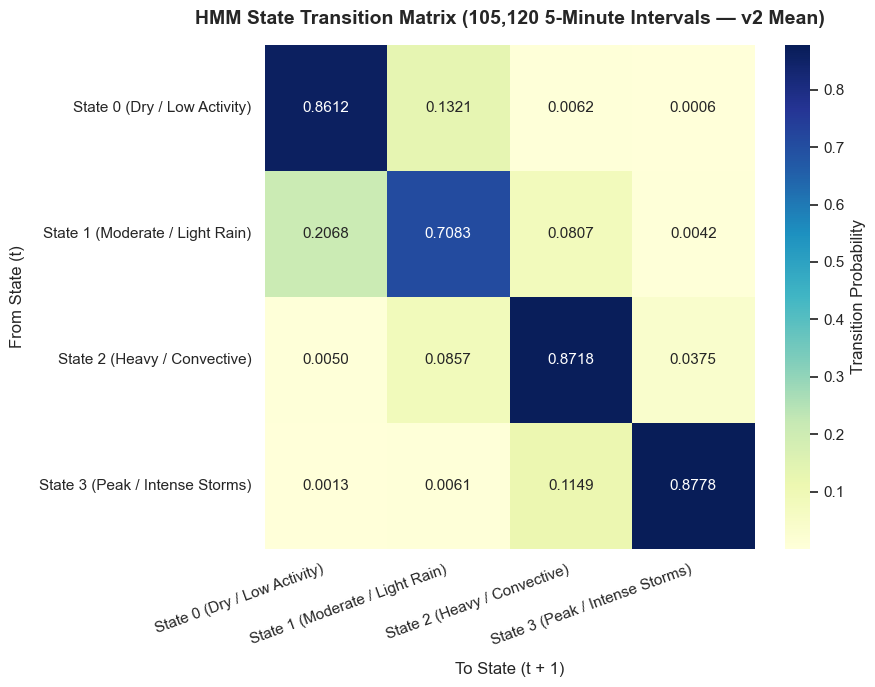

                                 State 0 (Dry / Low Activity)  \
State 0 (Dry / Low Activity)                         0.861201   
State 1 (Moderate / Light Rain)                      0.206821   
State 2 (Heavy / Convective)                         0.005023   
State 3 (Peak / Intense Storms)                      0.001257   

                                 State 1 (Moderate / Light Rain)  \
State 0 (Dry / Low Activity)                            0.132072   
State 1 (Moderate / Light Rain)                         0.708326   
State 2 (Heavy / Convective)                            0.085654   
State 3 (Peak / Intense Storms)                         0.006074   

                                 State 2 (Heavy / Convective)  \
State 0 (Dry / Low Activity)                         0.006168   
State 1 (Moderate / Light Rain)                      0.080655   
State 2 (Heavy / Convective)                         0.871792   
State 3 (Peak / Intense Storms)                      0.114881   

       

In [17]:
# Compute 4x4 empirical transition matrix across 105,120 intervals
trans_matrix = np.zeros((n_states, n_states))
for t in range(len(clim_105120) - 1):
    i = clim_105120['hmm_state'].iloc[t]
    j = clim_105120['hmm_state'].iloc[t+1]
    trans_matrix[i, j] += 1

# Normalize transition matrix rows to probabilities
trans_matrix_prob = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)

# Plot Transition Matrix Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(trans_matrix_prob, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=state_names, yticklabels=state_names,
            cbar_kws={'label': 'Transition Probability'})
plt.title("HMM State Transition Matrix (105,120 5-Minute Intervals — v2 Mean)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("To State (t + 1)", fontsize=12, labelpad=10)
plt.ylabel("From State (t)", fontsize=12, labelpad=10)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print Transition Probabilities DataFrame
trans_df = pd.DataFrame(trans_matrix_prob, index=state_names, columns=state_names)
print(trans_df)

## Step 5: Visualize 105,120-Interval Climatological Regimes & State Transitions
We plot the 105,120 5-minute annual rainfall profile colored by hidden state transitions across the 365 days of the year.

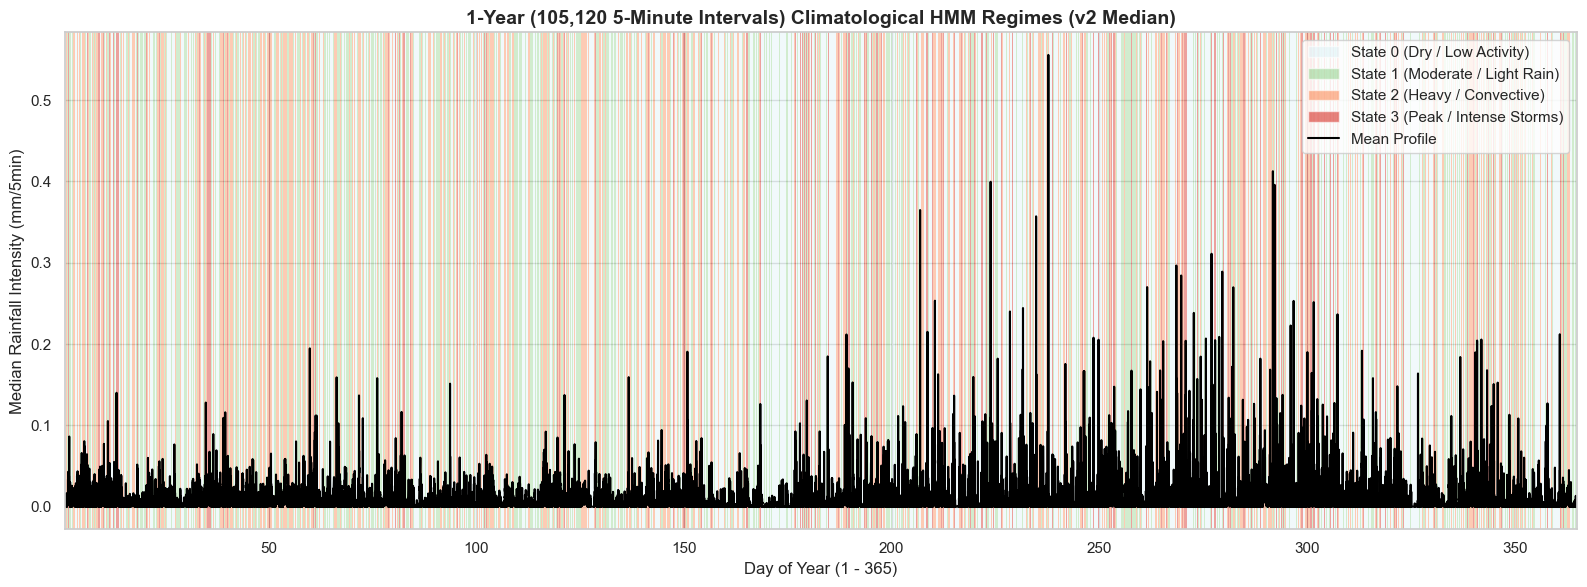

In [22]:
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

fig, ax = plt.subplots(figsize=(16, 6))
days = clim_105120.index / 288.0

# Background shading for HMM states across 105,120 intervals
current_state = clim_105120['hmm_state'].iloc[0]
start_idx = 0

for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state'].iloc[i] != current_state or i == len(clim_105120) - 1:
        ax.axvspan(days[start_idx], days[i], color=colors[current_state], alpha=0.45, linewidth=0)
        current_state = clim_105120['hmm_state'].iloc[i]
        start_idx = i

ax.plot(days, clim_105120['mean_intensity'], color='black', linewidth=1.5, label='Mean Profile')

legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='black', lw=1.5, label='Mean Profile'))

ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological HMM Regimes (v2 Median)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Median Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlim(1, 365)

plt.tight_layout()
plt.show()

## Step 6: HMM Regime Characterization Summary
We aggregate statistics (smoothed median intensity, mean intensity, interval count, and percentage of year) for each of the 4 discovered HMM states across the 105,120 intervals.

In [9]:
summary_df = clim_105120.groupby('hmm_state')[['median_intensity_smooth', 'mean_intensity_smooth']].mean()
summary_df.columns = ['Mean Smoothed Median (mm/5min)', 'Mean Intensity (mm/5min)']
summary_df['Interval_Count'] = clim_105120.groupby('hmm_state').size()
summary_df['Pct_of_Year'] = (summary_df['Interval_Count'] / len(clim_105120) * 100).round(2)
summary_df.index = state_names
print(summary_df)

                                 Mean Smoothed Median (mm/5min)  ...  Pct_of_Year
State 0 (Dry / Low Activity)                           0.000000  ...        56.89
State 1 (Moderate / Light Rain)                        0.000005  ...        28.74
State 2 (Heavy / Convective)                           0.000027  ...        11.56
State 3 (Peak / Intense Storms)                        0.000061  ...         2.81

[4 rows x 4 columns]


## Step 7: Broadcast 105,120-Interval HMM State Sequence to Full 5-Minute Dataset
We map the 105,120 5-minute HMM state sequence (`hmm_state` 0–3) back to each 5-minute record in the 10-year dataset (1,051,200 records) based on `annual_interval_idx` and export the v2 datasets.

In [10]:
# Create mapping from annual_interval_idx (0 to 105,119) to HMM state
interval_state_map = clim_105120['hmm_state'].to_dict()

# Broadcast 105,120 HMM state to full 5-minute dataset
df_5min_full['hmm_state'] = df_5min_full['annual_interval_idx'].map(interval_state_map)

# Fill leap-day records if any
if df_5min_full['hmm_state'].isna().any():
    last_valid_state = int(clim_105120['hmm_state'].iloc[-1])
    df_5min_full['hmm_state'] = df_5min_full['hmm_state'].fillna(last_valid_state)

df_5min_full['hmm_state'] = df_5min_full['hmm_state'].astype(int)
df_5min_full['date'] = df_5min_full['datetime'].dt.strftime('%d/%m/%Y')
df_5min_full['time'] = df_5min_full['datetime'].dt.strftime('%H:%M:%S')

print("Broadcasting HMM State Sequence Complete!")
print(f"5-Minute Labeled Dataset Shape: {df_5min_full.shape}")
print("\nDistribution of HMM States in 5-Minute Dataset:")
print(df_5min_full['hmm_state'].value_counts().sort_index())

# Save labeled 5-minute dataset with hmm_state column
output_dir = '../data/rainfall/astlingen/hmm_datasets'
if not os.path.exists(output_dir):
    output_dir = 'data/rainfall/astlingen/hmm_datasets'
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(output_dir, 'dataset_with_105120_v2_fit_hmm.csv')
df_5min_full[['date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].to_csv(output_csv, index=False)
print(f"Saved 5-minute dataset with 105,120-fitted HMM states (v2) to: {output_csv}")

print(df_5min_full[['datetime', 'date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].head(10))

Broadcasting HMM State Sequence Complete!
5-Minute Labeled Dataset Shape: (1051200, 9)

Distribution of HMM States in 5-Minute Dataset:
hmm_state
0    598844
1    301376
2    121420
3     29560
Name: count, dtype: int64
Saved 5-minute dataset with 105,120-fitted HMM states (v2) to: data/rainfall/astlingen/hmm_datasets/dataset_with_105120_v2_fit_hmm.csv
             datetime        date  ... day_of_year  hmm_state
0 2000-01-01 00:00:00  01/01/2000  ...           1          1
1 2000-01-01 00:05:00  01/01/2000  ...           1          1
2 2000-01-01 00:10:00  01/01/2000  ...           1          1
3 2000-01-01 00:15:00  01/01/2000  ...           1          1
4 2000-01-01 00:20:00  01/01/2000  ...           1          1
5 2000-01-01 00:25:00  01/01/2000  ...           1          1
6 2000-01-01 00:30:00  01/01/2000  ...           1          1
7 2000-01-01 00:35:00  01/01/2000  ...           1          1
8 2000-01-01 00:40:00  01/01/2000  ...           1          1
9 2000-01-01 00:45:00  01

## Step 8: Visualize 5-Minute Time Series Sample with Broadcasted HMM States
We plot a sample 14-day window of 5-minute rainfall intensity overlaying the broadcasted HMM state background shading.

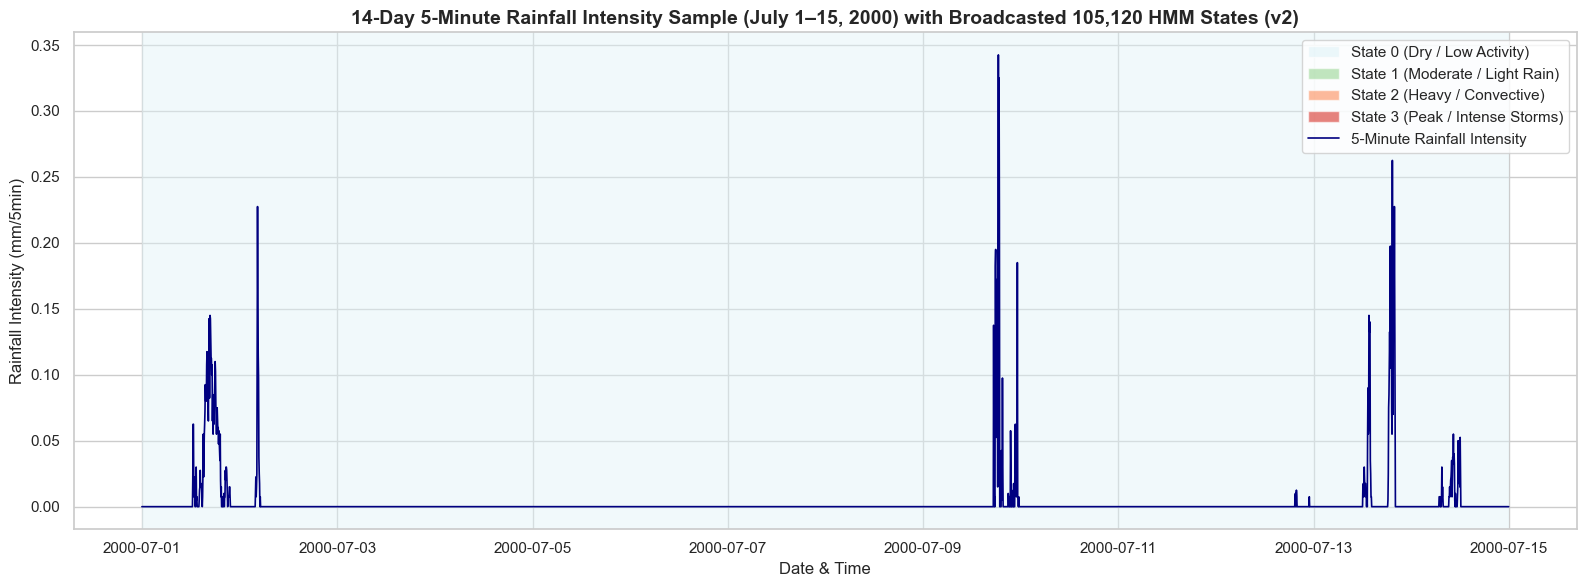

In [11]:
# Sample 14-day window (July 1 to July 15, 2000)
sample_df = df_5min_full[(df_5min_full['datetime'] >= '2000-07-01') & (df_5min_full['datetime'] < '2000-07-15')].copy()

fig, ax = plt.subplots(figsize=(16, 6))

times = sample_df['datetime']
rain = sample_df['rainfall_intensity']
states = sample_df['hmm_state'].values

# Background shading for broadcasted HMM states
current_st = states[0]
start_t = times.iloc[0]

for i in range(1, len(sample_df)):
    if states[i] != current_st or i == len(sample_df) - 1:
        ax.axvspan(start_t, times.iloc[i], color=colors[current_st], alpha=0.45, linewidth=0)
        current_st = states[i]
        start_t = times.iloc[i]

ax.plot(times, rain, color='navy', linewidth=1.2, label='5-Minute Rainfall Intensity')

legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='navy', lw=1.2, label='5-Minute Rainfall Intensity'))

ax.set_title('14-Day 5-Minute Rainfall Intensity Sample (July 1–15, 2000) with Broadcasted 105,120 HMM States (v2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()